# Parameters tuning for metrics computation

Evaluating the parameters influence of the speed QP formulation.

## Imports 

In [1]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from metrics import l2_error, rodrigues_error

In [2]:
def parse_pose_matrix(matrix):
    """Convert a string of a matrix into a NumPy array."""
    if isinstance(matrix, str):
        return np.array(ast.literal_eval(matrix))
    else:
        return np.array(matrix)

## Parameters influence 

* ### Proportionnal corrector $K_p$

In [3]:
mean_l_pos_err, mean_r_pos_err = [], []
mean_l_rot_err, mean_r_rot_err = [], []

for kp in [
    "0010",
    "0025",
    "0050",
    "0075",
    "0100",
    "0125",
    "0150",
    "0175",
    "0200",
    "0300",
    "0400",
    "0500",
    "0600",
    "0750",
    "1000",
]:
    filepath_num = f"data/num_circle_data_kp{kp}.csv"
    df_num2 = pd.read_csv(filepath_num, sep=",", header=0).copy()

    l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
    r_pos_errs, r_rot_errs, r_comb_errs = [], [], []
    for _, row in df_num2.iterrows():
        l_pose = parse_pose_matrix(row["l_pose"])
        l_real = parse_pose_matrix(row["l_real_pose"])

        l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
        l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

        l_pos_errs.append(l_pos)
        l_rot_errs.append(l_rot)

        r_pose = parse_pose_matrix(row["r_pose"])
        r_real = parse_pose_matrix(row["r_real_pose"])

        r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
        r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

        r_pos_errs.append(r_pos)
        r_rot_errs.append(r_rot)

    mean_l_pos_err.append(np.array(l_pos_errs).mean())
    mean_r_pos_err.append(np.array(r_pos_errs).mean())
    mean_l_rot_err.append(np.array(l_rot_errs).mean())
    mean_r_rot_err.append(np.array(r_rot_errs).mean())

### Display plots

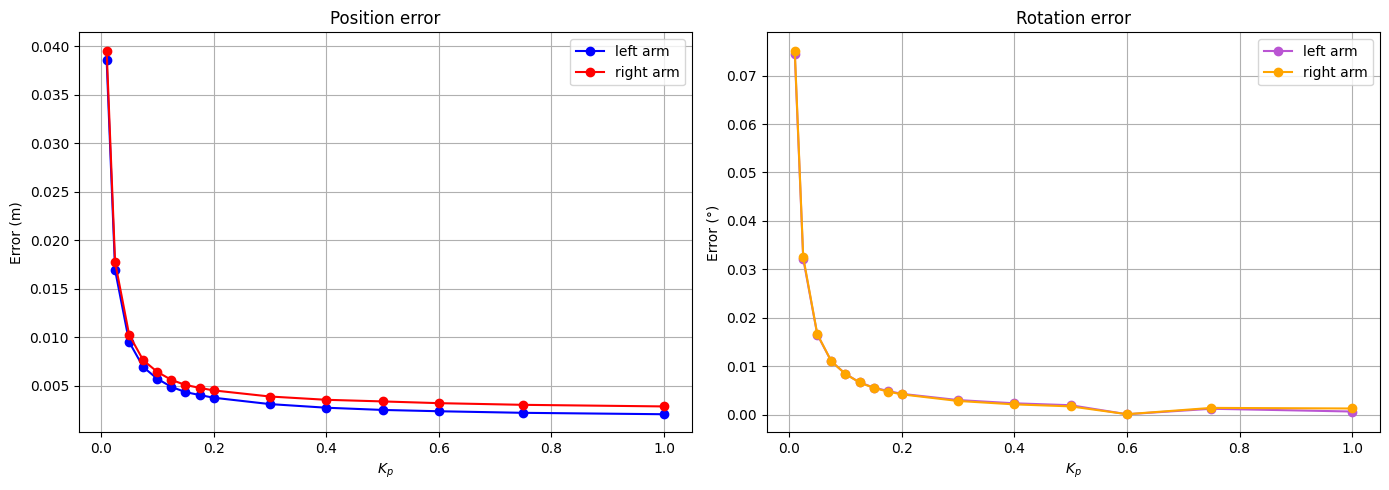

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

Kp = [0.01, 0.025, 0.050, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.3, 0.4, 0.5, 0.6, 0.75, 1.0]

axes[0].plot(Kp, mean_l_pos_err, label="left arm", color="b", marker="o")
axes[0].plot(Kp, mean_r_pos_err, label="right arm", color="r", marker="o")
axes[0].set_title("Position error")
axes[0].set_ylabel("Error (m)")
axes[0].set_xlabel("$K_p$")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(Kp, np.rad2deg(mean_l_rot_err), label="left arm", color="mediumorchid", marker="o")
axes[1].plot(Kp, np.rad2deg(mean_r_rot_err), label="right arm", color="orange", marker="o")
axes[1].set_title("Rotation error")
axes[1].set_ylabel("Error (°)")
axes[1].set_xlabel("$K_p$")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

* ### Damping factor $\lambda_v$

In [5]:
mean_l_pos_err, mean_r_pos_err = [], []
mean_l_rot_err, mean_r_rot_err = [], []

for step in ["075e10", "075e9", "075e8", "075e7", "075e6", "075e5", "075e4", "075e3", "075e2", "075e1"]:
    filepath_num = f"data/num_circle_data_l{step}.csv"
    df_num2 = pd.read_csv(filepath_num, sep=",", header=0).copy()

    l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
    r_pos_errs, r_rot_errs, r_comb_errs = [], [], []
    for _, row in df_num2.iterrows():
        l_pose = parse_pose_matrix(row["l_pose"])
        l_real = parse_pose_matrix(row["l_real_pose"])

        l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
        l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

        l_pos_errs.append(l_pos)
        l_rot_errs.append(l_rot)

        r_pose = parse_pose_matrix(row["r_pose"])
        r_real = parse_pose_matrix(row["r_real_pose"])

        r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
        r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

        r_pos_errs.append(r_pos)
        r_rot_errs.append(r_rot)

    mean_l_pos_err.append(np.array(l_pos_errs).mean())
    mean_r_pos_err.append(np.array(r_pos_errs).mean())
    mean_l_rot_err.append(np.array(l_rot_errs).mean())
    mean_r_rot_err.append(np.array(r_rot_errs).mean())

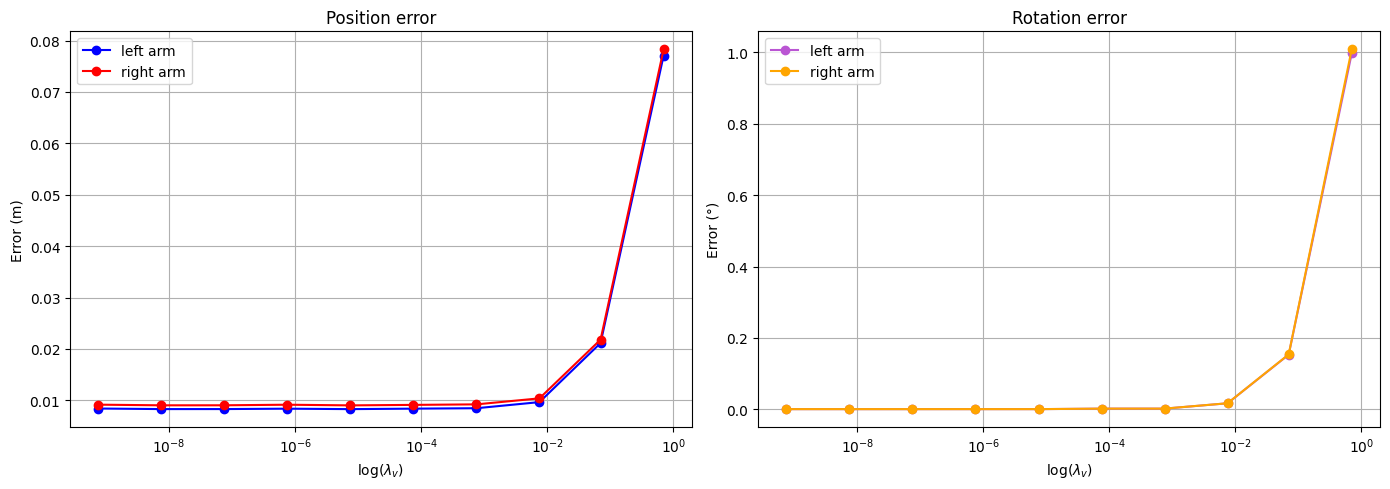

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

_lambda = [7.5e-10, 7.5e-9, 7.5e-8, 7.5e-7, 7.5e-6, 7.5e-5, 7.5e-4, 7.5e-3, 7e-2, 7e-1]

axes[0].plot(_lambda, mean_l_pos_err, label="left arm", color="b", marker="o")
axes[0].plot(_lambda, mean_r_pos_err, label="right arm", color="r", marker="o")
axes[0].set_title("Position error")
axes[0].set_ylabel("Error (m)")
axes[0].set_xlabel("$\\log(\\lambda_v)$")
axes[0].set_xscale("log")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(_lambda, np.rad2deg(mean_l_rot_err), label="left arm", color="mediumorchid", marker="o")
axes[1].plot(_lambda, np.rad2deg(mean_r_rot_err), label="right arm", color="orange", marker="o")
axes[1].set_title("Rotation error")
axes[1].set_ylabel("Error (°)")
axes[1].set_xlabel("$\\log(\\lambda_v)$")
axes[1].set_xscale("log")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()